# Alternative Motor Imagery Benchmark

This notebook implements a **alternative cross-subject benchmark** for motor imagery classification using a Riemannian geometry pipeline instead of the baseline CSP + LDA approach.

**Model:** Covariance estimation + Tangent Space projection + Logistic Regression  
**Evaluation:** Cross-subject (train on all subjects except one, test on held-out subject)  
**Dataset:** BNCI2014_001 (9 subjects, 2 sessions, left vs right hand motor imagery)  

# 1. Setup

## 1.1. Imports

In [1]:
# Reproducible setup
import warnings
warnings.filterwarnings('ignore')

import builtins
import json
from datetime import datetime
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import moabb
import pyriemann

# MOABB imports
from moabb.datasets import BNCI2014_001
from moabb.evaluations import CrossSubjectEvaluation
from moabb.paradigms import LeftRightImagery

# pyRiemann pipeline components
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

# scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1.2. Create artifact directory

In [2]:
# Fixed artifact directory (overwrite existing files on save)
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
ARTIFACT_DIR = BASE_DIR / 'artifacts' / '03_improvement_pipeline'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Artifact directory: {ARTIFACT_DIR}')

Artifact directory: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_improvement_pipeline


## 1.3. Initialize Logger

In [3]:
# Reset log file each time this setup cell is run
LOG_PATH = ARTIFACT_DIR / 'run.log'
if '_LOG_FILE_HANDLE' in globals() and _LOG_FILE_HANDLE and not _LOG_FILE_HANDLE.closed:
    _LOG_FILE_HANDLE.close()
_LOG_FILE_HANDLE = open(LOG_PATH, 'w', buffering=1)

if not hasattr(builtins, '_ORIGINAL_PRINT'):
    builtins._ORIGINAL_PRINT = builtins.print

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop('sep', ' ')
    end = kwargs.pop('end', '\n')
    flush = kwargs.pop('flush', False)
    file = kwargs.pop('file', None)

    message = sep.join(str(arg) for arg in args)
    leading_newlines = len(message) - len(message.lstrip('\n'))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text)
            if flush:
                sys.__stdout__.flush()
        else:
            file.write(text)
            if flush and hasattr(file, 'flush'):
                file.flush()

    if leading_newlines > 0:
        blanks = '\n' * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        stamped = f'[{ts}] {message_body}'
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

print(f'Logging to: {LOG_PATH}')

[2026-04-13 15:27:50] Logging to: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_improvement_pipeline/run.log


## 1.4. Save Plots

In [4]:
def save_plot(filename):
    path = ARTIFACT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')

## 1.5. Save Tables

In [5]:
def save_table(data, filename, index=True):
    path = ARTIFACT_DIR / filename
    suffix = path.suffix.lower()

    if isinstance(data, pd.Series):
        data = data.to_frame()

    if suffix == '.csv':
        data.to_csv(path, index=index)
    elif suffix == '.json':
        if isinstance(data, pd.DataFrame):
            data.to_json(path, orient='records', indent=2)
        else:
            with open(path, 'w') as handle:
                json.dump(data, handle, indent=2)
    else:
        raise ValueError(f'Unsupported table format: {suffix}')

    print(f'Saved table: {path}')

def get_first_matching_column(frame, candidates):
    lower_lookup = {column.lower(): column for column in frame.columns}
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
        lowered = candidate.lower()
        if lowered in lower_lookup:
            return lower_lookup[lowered]
    raise KeyError(f'None of the expected columns were found: {candidates}. Available columns: {list(frame.columns)}')

# 2. Data

## 2.1. Dataset Setup

In [6]:
# Instantiate dataset and paradigm
dataset = BNCI2014_001()
paradigm = LeftRightImagery()

print('Dataset and paradigm initialized.')
print(f'Dataset: {dataset.__class__.__name__}')
print(f'Paradigm: {paradigm.__class__.__name__}')

[2026-04-13 15:27:50] Dataset and paradigm initialized.
[2026-04-13 15:27:50] Dataset: BNCI2014_001
[2026-04-13 15:27:50] Paradigm: LeftRightImagery


## 2.2. Dataset Metadata Inspection

In [7]:
print('=' * 60)
print('DATASET INFORMATION')
print('=' * 60)
print(f'Number of subjects: {len(dataset.subject_list)}')
print(f'Subject IDs: {dataset.subject_list}')
print(f'Number of sessions: {dataset.n_sessions}')
print(f'Event IDs (all classes): {dataset.event_id}')

[2026-04-13 15:27:50] ============================================================
[2026-04-13 15:27:50] DATASET INFORMATION
[2026-04-13 15:27:50] ============================================================
[2026-04-13 15:27:50] Number of subjects: 9
[2026-04-13 15:27:50] Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-13 15:27:50] Number of sessions: 2
[2026-04-13 15:27:50] Event IDs (all classes): {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}


In [8]:
print('\n' + '=' * 60)
print('PARADIGM INFORMATION')
print('=' * 60)
print(f'Frequency filters: {paradigm.filters}')
print(f'Paradigm events (left/right only): {paradigm.events}')


[2026-04-13 15:27:50] ============================================================
[2026-04-13 15:27:50] PARADIGM INFORMATION
[2026-04-13 15:27:50] ============================================================
[2026-04-13 15:27:50] Frequency filters: [[8, 32]]
[2026-04-13 15:27:50] Paradigm events (left/right only): ['left_hand', 'right_hand']


# 3. Improvement Pipeline

**Riemannian geometry pipeline:**  
This benchmark replaces Euclidean CSP features with covariance matrices projected into tangent space. This is a common and effective classical approach for motor imagery EEG.

**Why logistic regression:**  
After tangent-space projection, logistic regression provides a simple linear decision boundary with strong default behavior and minimal tuning.

The goal is not to over-tune the model, but to test whether a stronger classical representation improves cross-subject generalization under the same evaluation setup as the baseline notebook.

## 3.1. Pipeline Definition

In [9]:
# Build the improved pipeline
# Covariances estimate trial covariance matrices, tangent space vectorizes them,
# and logistic regression performs classification in the resulting feature space.
pipeline = make_pipeline(
    Covariances(estimator='oas'),
    TangentSpace(metric='riemann'),
    LogisticRegression(max_iter=1000, random_state=SEED)
)

# Create a dictionary for MOABB evaluation
pipelines = {'RG+LR': pipeline}

print('Improved pipeline created:')
print(pipeline)

[2026-04-13 15:27:50] Improved pipeline created:
[2026-04-13 15:27:50] Pipeline(steps=[('covariances', Covariances(estimator='oas')),
                ('tangentspace', TangentSpace()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])


## 3.2. Cross-Subject Evaluation Setup

In [10]:
# Create cross-subject evaluation object
evaluation = CrossSubjectEvaluation(
    paradigm=paradigm,
    datasets=[dataset],
    overwrite=False
)

print('Cross-subject evaluation configured.')

[2026-04-13 15:27:50] Cross-subject evaluation configured.


## 3.3. Run Improvement Benchmark

In [11]:
# Run the evaluation
print('Running cross-subject evaluation...')
results = evaluation.process(pipelines)

score_col = get_first_matching_column(results, ['score', 'scores', 'accuracy'])
subject_col = get_first_matching_column(results, ['subject', 'subjects', 'subject_id'])

print('\nEvaluation complete!')
print(f'Results shape: {results.shape}')
print(f'Results columns: {list(results.columns)}')

save_table(results, 'results.csv', index=False)

[2026-04-13 15:27:50] Running cross-subject evaluation...


BNCI2014-001-CrossSubject: 100%|██████████| 9/9 [00:15<00:00,  1.70s/it]



[2026-04-13 15:28:23] Evaluation complete!
[2026-04-13 15:28:23] Results shape: (18, 9)
[2026-04-13 15:28:23] Results columns: ['score', 'time', 'samples', 'subject', 'session', 'channels', 'n_sessions', 'dataset', 'pipeline']
[2026-04-13 15:28:23] Saved table: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_improvement_pipeline/results.csv


## 3.4. Inspect Results

In [12]:
print('\n' + '=' * 60)
print('Results:')
print('=' * 60)
print(results)

summary_metrics = {
    'mean_score': float(results[score_col].mean()),
    'std_score': float(results[score_col].std()),
    'min_score': float(results[score_col].min()),
    'max_score': float(results[score_col].max()),
}

print('\n' + '=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f"Mean score: {summary_metrics['mean_score']:.4f}")
print(f"Std score: {summary_metrics['std_score']:.4f}")
print(f"Min score: {summary_metrics['min_score']:.4f}")
print(f"Max score: {summary_metrics['max_score']:.4f}")

save_table(pd.DataFrame([summary_metrics]), 'summary_metrics.csv', index=False)
save_table(summary_metrics, 'summary_metrics.json', index=False)


[2026-04-13 15:28:23] ============================================================
[2026-04-13 15:28:23] Results:
[2026-04-13 15:28:23] ============================================================
[2026-04-13 15:28:23]        score      time  samples subject session  channels  n_sessions       dataset pipeline
0   0.907215  1.741461   2304.0       1  0train        22           2  BNCI2014-001    RG+LR
1   0.915509  1.741461   2304.0       1   1test        22           2  BNCI2014-001    RG+LR
2   0.564043  1.569878   2304.0       2  0train        22           2  BNCI2014-001    RG+LR
3   0.506366  1.569878   2304.0       2   1test        22           2  BNCI2014-001    RG+LR
4   0.983025  1.550856   2304.0       3  0train        22           2  BNCI2014-001    RG+LR
5   0.979745  1.550856   2304.0       3   1test        22           2  BNCI2014-001    RG+LR
6   0.793403  1.527638   2304.0       4  0train        22           2  BNCI2014-001    RG+LR
7   0.819637  1.527638   2304.0     

# 4. Per-Subject Analysis

## 4.1. Get Subject Performance

In [13]:
# Compute per-subject scores
per_subject_scores = results.groupby(subject_col)[score_col].mean().sort_values()

print('=' * 60)
print('PER-SUBJECT PERFORMANCE (sorted from worst to best)')
print('=' * 60)
print(per_subject_scores)

print(f'\nBest performing subject: {per_subject_scores.idxmax()} ({per_subject_scores.max():.4f})')
print(f'Worst performing subject: {per_subject_scores.idxmin()} ({per_subject_scores.min():.4f})')

per_subject_scores_df = per_subject_scores.rename('score').reset_index()
save_table(per_subject_scores_df, 'per_subject_scores.csv', index=False)

[2026-04-13 15:28:23] ============================================================
[2026-04-13 15:28:23] PER-SUBJECT PERFORMANCE (sorted from worst to best)
[2026-04-13 15:28:23] ============================================================
[2026-04-13 15:28:23] subject
2    0.535204
5    0.624711
7    0.695023
6    0.710745
9    0.757716
4    0.806520
1    0.911362
8    0.966049
3    0.981385
Name: score, dtype: float32

[2026-04-13 15:28:23] Best performing subject: 3 (0.9814)
[2026-04-13 15:28:23] Worst performing subject: 2 (0.5352)
[2026-04-13 15:28:23] Saved table: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_improvement_pipeline/per_subject_scores.csv


## 4.2. Visualize Per-Subject Performance

[2026-04-13 15:28:23] Saved plot: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_improvement_pipeline/per_subject_accuracy_bar.png


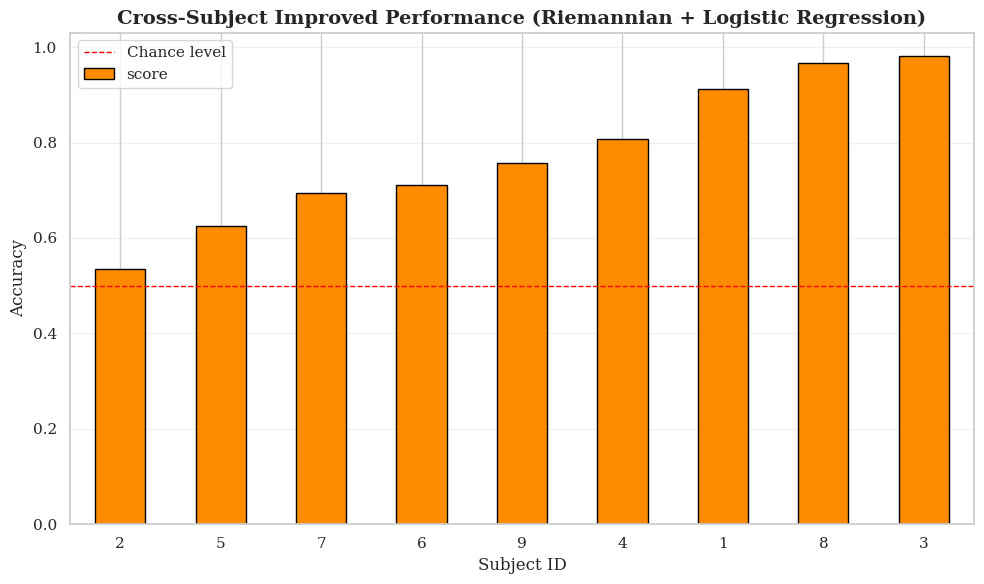

[2026-04-13 15:28:23] Saved plot: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_improvement_pipeline/performance_distribution_boxplot.png


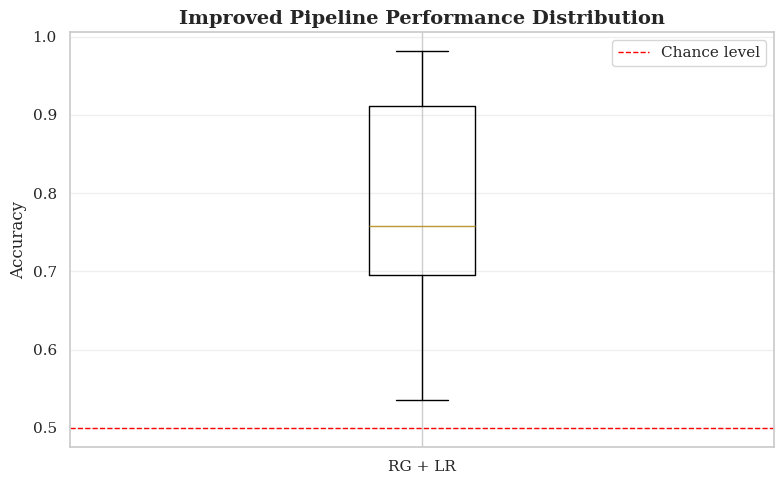

In [14]:
plt.figure(figsize=(10, 6))
per_subject_scores.plot(kind='bar', color='darkorange', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Subject Improved Performance (Riemannian + Logistic Regression)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('per_subject_accuracy_bar.png')
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([per_subject_scores.values], labels=['RG + LR'])
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Improved Pipeline Performance Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('performance_distribution_boxplot.png')
plt.show()

## 4.3. Identify Low-Performing Subjects

In [15]:
print('=' * 60)
print('LOW-PERFORMING SUBJECTS (candidates for comparison)')
print('=' * 60)

bottom_subjects = per_subject_scores.head(3)
print('Bottom 3 subjects:')
for subject, score in bottom_subjects.items():
    print(f'  Subject {subject}: {score:.4f}')

median_score = per_subject_scores.median()
below_median = int((per_subject_scores < median_score).sum())

print(f'Median score: {median_score:.4f}')
print(f'Subjects below median: {below_median}/{len(per_subject_scores)}')
print('These subjects will be carried forward into the comparison notebook.')

[2026-04-13 15:28:23] ============================================================
[2026-04-13 15:28:23] LOW-PERFORMING SUBJECTS (candidates for comparison)
[2026-04-13 15:28:23] ============================================================
[2026-04-13 15:28:23] Bottom 3 subjects:
[2026-04-13 15:28:23]   Subject 2: 0.5352
[2026-04-13 15:28:23]   Subject 5: 0.6247
[2026-04-13 15:28:23]   Subject 7: 0.6950
[2026-04-13 15:28:23] Median score: 0.7577
[2026-04-13 15:28:23] Subjects below median: 4/9
[2026-04-13 15:28:23] These subjects will be carried forward into the comparison notebook.
